In [30]:
import sqlite3
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [44]:
databaseold = "crypto_historical_data_old.db"
database = "crypto_historical_data.db"

In [3]:
with sqlite3.connect(databaseold) as conn:
    df = pd.read_sql("SELECT DISTINCT * FROM btc_price", conn)

df['time_close'] = pd.to_datetime(df['time_close'], format='ISO8601')
df

,time_close,open,high,low,close,volume
0,2010-07-17 00:00:00+00:00,0.049510,0.049510,0.049510,0.049510,9.902000e-01
1,2010-07-19 00:00:00+00:00,0.090900,0.093070,0.077230,0.080800,2.380020e+01
2,2010-07-20 00:00:00+00:00,0.074260,0.074740,0.074260,0.074740,4.569790e+00
3,2010-07-21 00:00:00+00:00,0.071710,0.079210,0.071710,0.079210,2.732590e+01
4,2010-07-22 00:00:00+00:00,0.059410,0.059410,0.050500,0.052480,5.317300e+00
...,...,...,...,...,...,...
5348,2025-03-15 00:00:00+00:00,84046.329961,84714.518047,83629.584050,84358.145808,8.568870e+09
5349,2025-03-16 00:00:00+00:00,84355.622110,84755.121006,82003.594389,82579.218025,1.303028e+10
5350,2025-03-17 00:00:00+00:00,82571.427596,84753.424550,82533.054094,84096.525045,1.486147e+10
5351,2025-03-18 00:00:00+00:00,84108.120306,84108.120306,81195.273606,82724.190523,1.551179e+10


In [4]:
df2 = pd.read_csv("Binance_BTCUSDT_d_28-07-2026.csv")
df2["time_close"] = pd.to_datetime(df2["Unix"], unit="ms")
df2 = df2[["time_close", "Open", "High", "Low", "Close"]]
df2 = df2.rename(columns={c: c.lower() for c in df2.columns})
df2

,time_close,open,high,low,close
0,2026-07-27,65400.00,65744.60,63605.56,63755.86
1,2026-07-26,64375.01,65577.00,64293.81,65399.99
2,2026-07-25,64140.00,64475.28,63810.00,64375.00
3,2026-07-24,65098.98,65808.59,63739.75,64139.99
4,2026-07-20,64722.55,65799.00,63100.00,65255.51
...,...,...,...,...,...
3235,2017-08-21,4069.13,4119.62,3911.79,4016.00
3236,2017-08-20,4120.98,4211.08,4032.62,4086.29
3237,2017-08-19,4108.37,4184.69,3850.00,4139.98
3238,2017-08-18,4285.08,4371.52,3938.77,4108.37


In [13]:
dfall = pd.concat([df, df2])
dfall = dfall.drop(columns="volume")
dfall['time_close'] = pd.to_datetime(df['time_close'], utc=True)

In [14]:
dfall = dfall.drop_duplicates(subset=['time_close'])

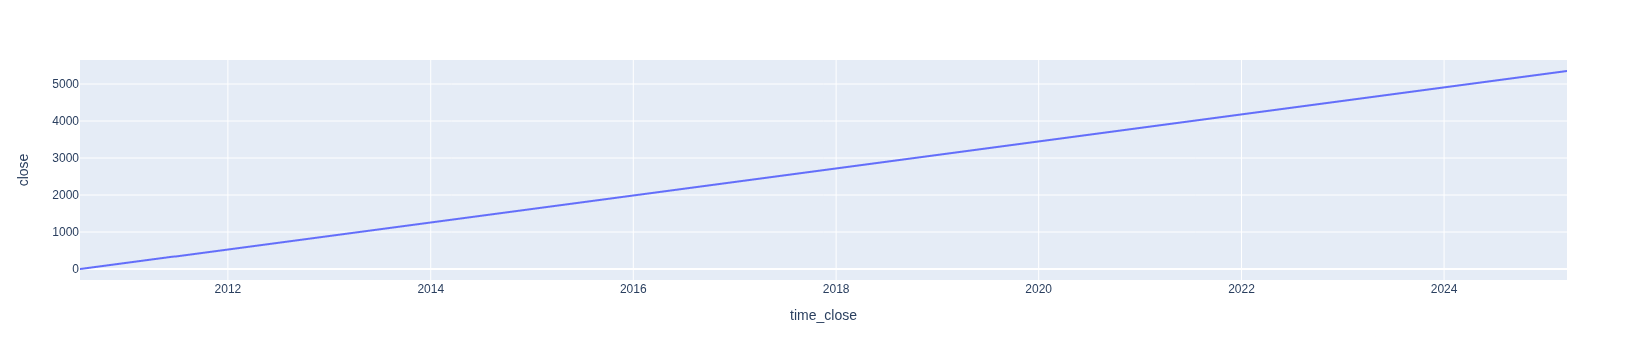

In [17]:
fig = px.line(dfall, x = "time_close", y="close")
fig.show()

In [26]:
df_sorted = dfall.sort_values(by="time_close")
df_sorted['close'] = pd.to_numeric(
    df_sorted['close'].astype(str).str.replace(r'[$,]', '', regex=True), 
    errors='coerce'
)
df_sorted

,time_close,open,high,low,close
0,2010-07-17 00:00:00+00:00,0.049510,0.049510,0.049510,0.049510
1,2010-07-19 00:00:00+00:00,0.090900,0.093070,0.077230,0.080800
2,2010-07-20 00:00:00+00:00,0.074260,0.074740,0.074260,0.074740
3,2010-07-21 00:00:00+00:00,0.071710,0.079210,0.071710,0.079210
4,2010-07-22 00:00:00+00:00,0.059410,0.059410,0.050500,0.052480
...,...,...,...,...,...
5348,2025-03-15 00:00:00+00:00,84046.329961,84714.518047,83629.584050,84358.145808
5349,2025-03-16 00:00:00+00:00,84355.622110,84755.121006,82003.594389,82579.218025
5350,2025-03-17 00:00:00+00:00,82571.427596,84753.424550,82533.054094,84096.525045
5351,2025-03-18 00:00:00+00:00,84108.120306,84108.120306,81195.273606,82724.190523


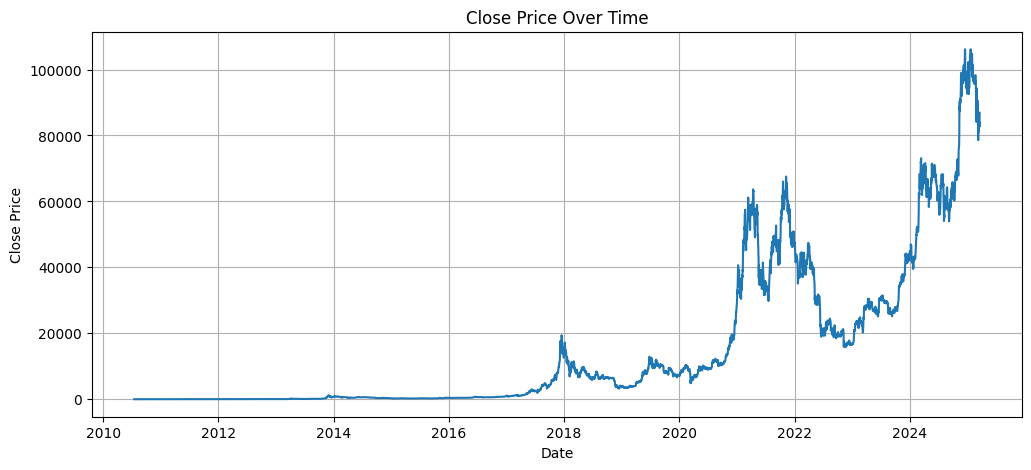

In [43]:
import matplotlib.pyplot as plt

# Ensure chronological sorting
df_clean = df_sorted

plt.figure(figsize=(12, 5))
plt.plot(df_clean["time_close"], df_clean["close"])
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Close Price Over Time")
plt.grid(True)
plt.show()

In [45]:
with sqlite3.connect(database) as conn:


    df_sorted.to_sql(
        name="btc_price",
        con=conn,
        if_exists="fail",  # Options: 'replace', 'append', or 'fail'
        index=False,  # Set to False to prevent saving the row index
    )


print("Successfully saved df_sorted to SQLite database!")

Successfully saved df_sorted to SQLite database!


In [29]:
print(df_sorted.columns)

Index(['time_close', 'open', 'high', 'low', 'close'], dtype='object')


In [33]:
print("FIRST 5 ROWS:")
print(df_sorted[["time_close", "close"]].head(5))

print("\nLAST 5 ROWS:")
print(df_sorted[["time_close", "close"]].tail(5))

FIRST 5 ROWS:
                 time_close    close
0 2010-07-17 00:00:00+00:00  0.04951
1 2010-07-19 00:00:00+00:00  0.08080
2 2010-07-20 00:00:00+00:00  0.07474
3 2010-07-21 00:00:00+00:00  0.07921
4 2010-07-22 00:00:00+00:00  0.05248

LAST 5 ROWS:
                    time_close         close
5348 2025-03-15 00:00:00+00:00  84358.145808
5349 2025-03-16 00:00:00+00:00  82579.218025
5350 2025-03-17 00:00:00+00:00  84096.525045
5351 2025-03-18 00:00:00+00:00  82724.190523
5352 2025-03-19 00:00:00+00:00  86891.759940


In [38]:
print("Is close sorted?", df_sorted["close"].is_monotonic_increasing)

Is close sorted? False
